- Dataset: https://archive.ics.uci.edu/dataset/359/news+aggregator

In [1]:
!pip install -q --upgrade numexpr bottleneck

In [3]:
import pandas as pd

s3_path = 'newsCorpora.csv'
df = pd.read_csv(s3_path, sep='\t',names=['ID','TITLE','URL','PUBLISHER','CATEGORY','STORY','HOSTNAME','TIMESTAMP'])

In [4]:
df.head()

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027


In [5]:
df.describe()

,ID,TIMESTAMP
count,422419.000000,4.224190e+05
mean,211536.764594,1.400445e+12
std,122102.839707,3.733088e+09
min,1.000000,1.394470e+12
25%,105801.500000,1.397349e+12
50%,211655.000000,1.399990e+12
75%,317273.500000,1.403775e+12
max,422937.000000,1.409229e+12


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 422419 entries, 0 to 422418
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   ID         422419 non-null  int64
 1   TITLE      422419 non-null  str  
 2   URL        422419 non-null  str  
 3   PUBLISHER  422417 non-null  str  
 4   CATEGORY   422419 non-null  str  
 5   STORY      422419 non-null  str  
 6   HOSTNAME   422419 non-null  str  
 7   TIMESTAMP  422419 non-null  int64
dtypes: int64(2), str(6)
memory usage: 112.6 MB


In [7]:
df_work = df.copy()

In [8]:
df_work=df_work[['TITLE','CATEGORY']]

In [9]:
df_work

,TITLE,CATEGORY
0,"Fed official says weak data caused by weather,...",b
1,Fed's Charles Plosser sees high bar for change...,b
2,US open: Stocks fall after Fed official hints ...,b
3,"Fed risks falling 'behind the curve', Charles ...",b
4,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,b
...,...,...
422414,Surgeons to remove 4-year-old's rib to rebuild...,m
422415,Boy to have surgery on esophagus after battery...,m
422416,Child who swallowed battery to have reconstruc...,m
422417,Phoenix boy undergoes surgery to repair throat...,m


In [10]:
my_dict = {

    'e':'Entertainment',
    'b':'Business',
    't':'Science',
    'm':'Health'

}

In [11]:
def update_category(x):
    return my_dict[x]

df_work['CATEGORY'] = df_work['CATEGORY'].apply(lambda x: update_category(x))

In [12]:
df_work

,TITLE,CATEGORY
0,"Fed official says weak data caused by weather,...",Business
1,Fed's Charles Plosser sees high bar for change...,Business
2,US open: Stocks fall after Fed official hints ...,Business
3,"Fed risks falling 'behind the curve', Charles ...",Business
4,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,Business
...,...,...
422414,Surgeons to remove 4-year-old's rib to rebuild...,Health
422415,Boy to have surgery on esophagus after battery...,Health
422416,Child who swallowed battery to have reconstruc...,Health
422417,Phoenix boy undergoes surgery to repair throat...,Health


In [14]:
import random

def get_random_title_by_category(category):
    filtered_df = df_work[df_work['CATEGORY']==category]
    return filtered_df['TITLE'].sample().values[0]

category = 'Entertainment'

random_title = get_random_title_by_category(category)

print(random_title)

Sue Townsend, creator of Adrian Mole, dies aged 68


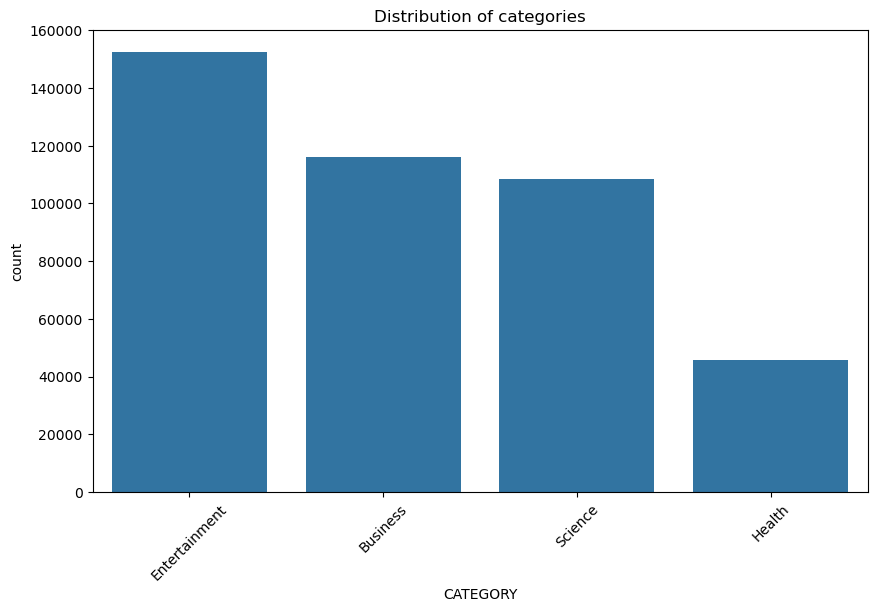

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df_work,x='CATEGORY',order=df_work['CATEGORY'].value_counts().index)
plt.title('Distribution of categories')
plt.xticks(rotation=45)
plt.show()

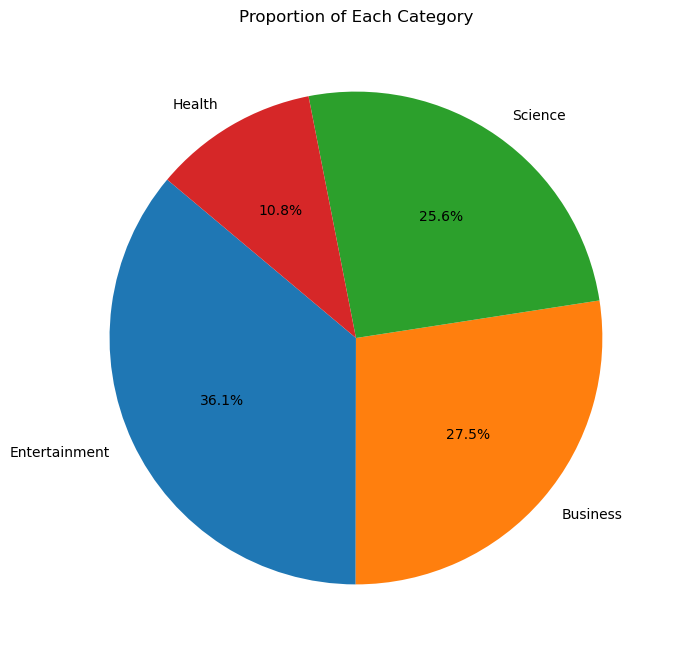

In [16]:
category_counts = df_work['CATEGORY'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts,labels=category_counts.index,autopct='%1.1f%%',startangle=140)
plt.title('Proportion of Each Category')
plt.show()